<a href="https://colab.research.google.com/github/simonesbasilio/streaming_churn_si/blob/master/Estatistica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação de Bibliotecas e Montagem do Google Drive
Nesta etapa, montamos o Google Drive para acessar a pasta com os dados.

In [1]:
from google.colab import drive
import pandas as pd

# Monta o Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# Carregamento e Análise dos Dados
Agora, definimos o caminho para o arquivo `clientes_base.csv` dentro da pasta `Business_Analytics_Fraude/Estatística` do seu Drive, carregamos em um DataFrame e exibimos as informações.

In [2]:
import pandas as pd

file_path = '/content/drive/My Drive/Business_Analytics_Fraude/Estatística/clientes_base.csv'

try:
    df = pd.read_csv(file_path)

    print("--- Primeiras Linhas do DataFrame ---")
    display(df.head())

    print("\n--- Tipos das Colunas ---")
    display(df.dtypes)

    print("\n--- Dimensões do DataFrame ---")
    linhas, colunas = df.shape
    print(f"Total de linhas (registros): {linhas}")
    print(f"Total de colunas: {colunas}")
except FileNotFoundError:
    print(f"Erro: Não foi possível encontrar o arquivo no caminho: {file_path}")

--- Primeiras Linhas do DataFrame ---


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,data_ultimo_acesso,data_extracao,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn
0,5746,36,BASICO,Anual,19.9,Sudeste,Indicacao,6,2023-04-11,NaN,2024-01-29,2024-01-31,15,276.0,NaN,0
1,4100,48,Padrão,Mensal,34.9,Sudeste,orgânico,8,2022-06-02,NaN,2024-01-30,2024-01-31,14,394.9,NaN,0
2,4690,48,Premium,Mensal,55.9,Nordeste,orgânico,4,2021-03-20,2022-11-17,2022-10-31,2024-01-31,5,257.0,PREÇO,1
3,3454,46,BASICO,Anual,1990.0,Sul,Google,10,2023-04-02,NaN,2024-01-13,2024-01-31,19,385.0,NaN,0
4,1437,46,Basico,Mensal,19.9,Norte,indicação,8,2023-04-21,NaN,2024-01-16,2024-01-31,11,205.3,NaN,0



--- Tipos das Colunas ---


,0
cliente_id,int64
idade,int64
plano,object
ciclo,object
valor_mensal,float64
regiao,object
canal_aquisicao,object
nps,int64
data_assinatura,object
data_cancelamento,object



--- Dimensões do DataFrame ---
Total de linhas (registros): 5025
Total de colunas: 16



=== Análise da Coluna: plano ===
Valores únicos e contagem:
plano
Basico     708
BASICO     677
básico     677
Padrao     665
Padrão     654
padrão     646
premium    513
Premium    485
Name: count, dtype: int64


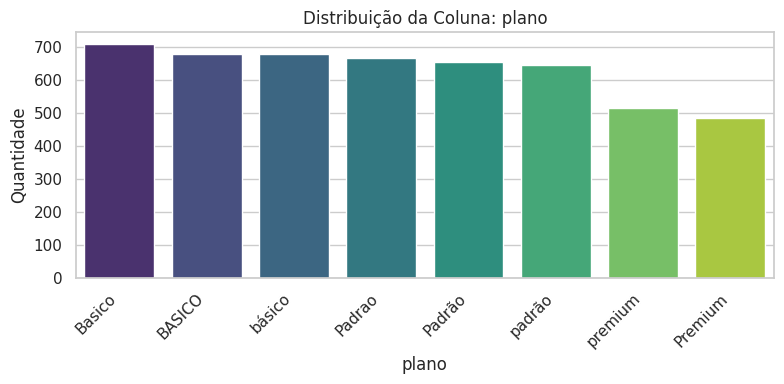


=== Análise da Coluna: ciclo ===
Valores únicos e contagem:
ciclo
Mensal    3794
Anual     1231
Name: count, dtype: int64


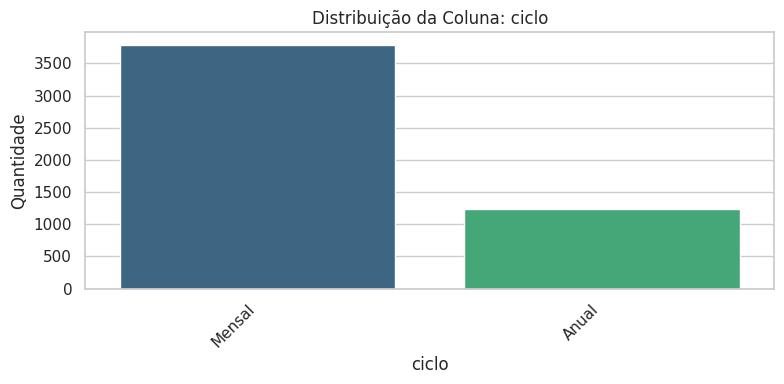


=== Análise da Coluna: regiao ===
Valores únicos e contagem:
regiao
Sudeste         2057
Nordeste         964
Sul              938
Centro-Oeste     488
Norte            408
?                170
Name: count, dtype: int64


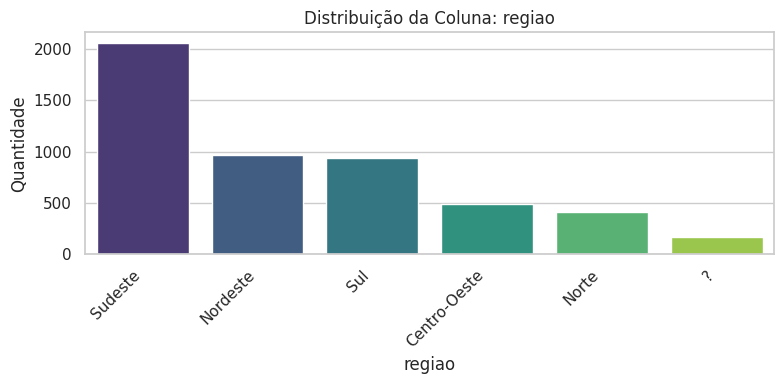


=== Análise da Coluna: canal_aquisicao ===
Valores únicos e contagem:
canal_aquisicao
Organico     781
orgânico     729
Indicacao    556
IG           529
indicação    526
Instagram    519
instagram    499
Google       452
google       434
Name: count, dtype: int64


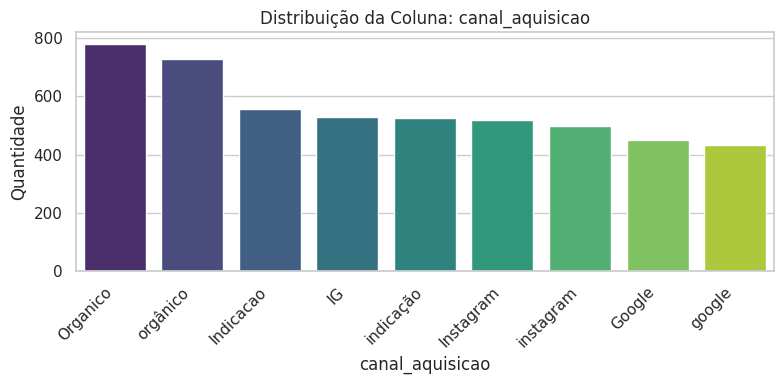

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeia possíveis variações de nomes de colunas para garantir que encontre mesmo com ou sem acentos
mapeamento_colunas = {
    'plano': 'plano',
    'ciclo': 'ciclo',
    'região': 'região',
    'regiao': 'região',
    'canal_aquisição': 'canal_aquisição',
    'canal_aquisicao': 'canal_aquisição'
}

# Encontrar o nome real da coluna no dataframe
colunas_existentes = {col.lower(): col for col in df.columns}
colunas_alvo = ['plano', 'ciclo', 'região', 'canal_aquisição']

sns.set_theme(style="whitegrid")

for col_desejada in colunas_alvo:
    # Normaliza para buscar de forma tolerante a acentuação
    col_busca = col_desejada.lower().replace('ã', 'a').replace('ç', 'c').replace('õ', 'o').replace('í', 'i')

    col_real = None
    for c_df in df.columns:
        c_df_busca = c_df.lower().replace('ã', 'a').replace('ç', 'c').replace('õ', 'o').replace('í', 'i')
        if c_df_busca == col_busca:
            col_real = c_df
            break

    if col_real:
        print(f"\n=== Análise da Coluna: {col_real} ===")

        # Contagem de valores únicos
        contagem = df[col_real].value_counts(dropna=False)
        print("Valores únicos e contagem:")
        print(contagem)

        # Plotagem
        plt.figure(figsize=(8, 4))
        sns.barplot(x=contagem.index.astype(str), y=contagem.values, palette="viridis", hue=contagem.index.astype(str), legend=False)

        plt.title(f"Distribuição da Coluna: {col_real}")
        plt.xlabel(col_real)
        plt.ylabel("Quantidade")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nAviso: Não foi possível encontrar a coluna para '{col_desejada}' no DataFrame.")

In [4]:
# 1. Contagem de nulos nas colunas
print("=== 1. Quantidade de Nulos por Coluna ===")
print(df.isnull().sum())
print("\n" + "="*40 + "\n")

# 2. Exemplo do DataFrame onde região é '?'
# Buscando a coluna 'regiao' (mesmo que com acento)
col_regiao = 'regiao' if 'regiao' in df.columns else 'região'
print(f"=== 2. Exemplo de registros onde a coluna '{col_regiao}' é '?' ===")
filtro_interrogacao = df[df[col_regiao] == '?']
print(f"Total de registros encontrados com '?': {len(filtro_interrogacao)}")
display(filtro_interrogacao.head())
print("\n" + "="*40 + "\n")

# 3. Tratamento da coluna 'plano'
print("=== 3. Padronizando a coluna 'plano' ===")
print("Antes da limpeza:")
print(df['plano'].value_counts(dropna=False))

df['plano'] = df['plano'].replace({
    'Basico': 'básico',
    'BASICO': 'básico',
    'básico': 'básico',
    'Padrao': 'padrão',
    'Padrão': 'padrão',
    'padrão': 'padrão',
    'Premium': 'premium',
    'premium': 'premium'
})

print("\nDepois da limpeza:")
print(df['plano'].value_counts(dropna=False))
print("\n" + "="*40 + "\n")

# 4. Tratamento da coluna 'canal_aquisicao'
col_canal = 'canal_aquisicao' if 'canal_aquisicao' in df.columns else 'canal_aquisição'
print(f"=== 4. Padronizando a coluna '{col_canal}' ===")
print("Antes da limpeza:")
print(df[col_canal].value_counts(dropna=False))

df[col_canal] = df[col_canal].replace({
    'Organico': 'orgânico',
    'orgânico': 'orgânico',
    'Indicacao': 'indicação',
    'indicação': 'indicação',
    'IG': 'instagram',
    'Instagram': 'instagram',
    'instagram': 'instagram',
    'Google': 'google',
    'google': 'google'
})

print("\nDepois da limpeza:")
print(df[col_canal].value_counts(dropna=False))

=== 1. Quantidade de Nulos por Coluna ===
cliente_id                   0
idade                        0
plano                        0
ciclo                        0
valor_mensal                 0
regiao                       0
canal_aquisicao              0
nps                          0
data_assinatura              0
data_cancelamento         3509
data_ultimo_acesso          50
data_extracao                0
dias_ativos_ult_mes          0
horas_assistidas_total       0
motivo_cancelamento       3509
churn                        0
dtype: int64


=== 2. Exemplo de registros onde a coluna 'regiao' é '?' ===
Total de registros encontrados com '?': 170


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,data_ultimo_acesso,data_extracao,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn
6,4918,37,Basico,Mensal,19.9,?,instagram,4,2023-10-12,2023-12-28,2023-12-09,2024-01-31,5,29.6,problema tecnico,1
10,4356,30,básico,Mensal,19.9,?,Organico,8,2020-12-22,NaN,2024-01-11,2024-01-31,15,900.0,NaN,0
34,1433,56,Padrão,Anual,3490.0,?,orgânico,9,2023-04-14,NaN,2024-01-22,2024-01-31,11,180.4,NaN,0
68,5259,41,padrão,Mensal,34.9,?,google,5,2023-05-03,NaN,2024-01-28,2024-01-31,8,139.9,NaN,0
135,2171,42,Padrão,Mensal,3490.0,?,orgânico,10,2021-04-16,NaN,2024-01-06,2024-01-31,10,505.2,NaN,0




=== 3. Padronizando a coluna 'plano' ===
Antes da limpeza:
plano
Basico     708
BASICO     677
básico     677
Padrao     665
Padrão     654
padrão     646
premium    513
Premium    485
Name: count, dtype: int64

Depois da limpeza:
plano
básico     2062
padrão     1965
premium     998
Name: count, dtype: int64


=== 4. Padronizando a coluna 'canal_aquisicao' ===
Antes da limpeza:
canal_aquisicao
Organico     781
orgânico     729
Indicacao    556
IG           529
indicação    526
Instagram    519
instagram    499
Google       452
google       434
Name: count, dtype: int64

Depois da limpeza:
canal_aquisicao
instagram    1547
orgânico     1510
indicação    1082
google        886
Name: count, dtype: int64


In [5]:
import numpy as np

# Substitui as ocorrências do caractere '?' por NaN (nulo)
df = df.replace('?', np.nan)

print("=== Nova contagem de nulos por coluna após a substituição de '?' ===")
print(df.isnull().sum())

=== Nova contagem de nulos por coluna após a substituição de '?' ===
cliente_id                   0
idade                        0
plano                        0
ciclo                        0
valor_mensal                 0
regiao                     170
canal_aquisicao              0
nps                          0
data_assinatura              0
data_cancelamento         3509
data_ultimo_acesso          50
data_extracao                0
dias_ativos_ult_mes          0
horas_assistidas_total       0
motivo_cancelamento       3509
churn                        0
dtype: int64


In [6]:
# Identifica as colunas que contêm 'data' no nome
colunas_data = [col for col in df.columns if 'data' in col.lower()]

print("=== Convertendo as colunas de data para Datetime ===")
for col in colunas_data:
    print(f"Convertendo a coluna: {col}")
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Exibe o tipo atualizado das colunas para confirmação
print("\n=== Tipos das colunas após a conversão ===")
print(df[colunas_data].dtypes)

=== Convertendo as colunas de data para Datetime ===
Convertendo a coluna: data_assinatura
Convertendo a coluna: data_cancelamento
Convertendo a coluna: data_ultimo_acesso
Convertendo a coluna: data_extracao

=== Tipos das colunas após a conversão ===
data_assinatura       datetime64[ns]
data_cancelamento     datetime64[ns]
data_ultimo_acesso    datetime64[ns]
data_extracao         datetime64[ns]
dtype: object


In [7]:
# Calcula a diferença em dias entre as colunas especificadas
df['diff_data_assinatura__data_cancelamento'] = (df['data_cancelamento'] - df['data_assinatura']).dt.days
df['diff_data_assinatura__data_ultimo_acessos'] = (df['data_ultimo_acesso'] - df['data_assinatura']).dt.days
df['diff_data_assinatura__data_extracao'] = (df['data_extracao'] - df['data_assinatura']).dt.days
df['diff_data_cancelamento__data_ultimo_acesso'] = (df['data_ultimo_acesso'] - df['data_cancelamento']).dt.days
df['diff_data_cancelamento__data_extracao'] = (df['data_extracao'] - df['data_cancelamento']).dt.days
df['diff_data_ultimo_acesso_data_extracao'] = (df['data_extracao'] - df['data_ultimo_acesso']).dt.days

# Lista das novas colunas criadas
novas_colunas = [
    'diff_data_assinatura__data_cancelamento',
    'diff_data_assinatura__data_ultimo_acessos',
    'diff_data_assinatura__data_extracao',
    'diff_data_cancelamento__data_ultimo_acesso',
    'diff_data_cancelamento__data_extracao',
    'diff_data_ultimo_acesso_data_extracao'
]

print("=== Amostra das novas colunas criadas (diferença em dias) ===")
display(df[novas_colunas].head())

=== Amostra das novas colunas criadas (diferença em dias) ===


,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acessos,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso_data_extracao
0,NaN,293.0,295,NaN,NaN,2.0
1,NaN,607.0,608,NaN,NaN,1.0
2,607.0,590.0,1047,-17.0,440.0,457.0
3,NaN,286.0,304,NaN,NaN,18.0
4,NaN,270.0,285,NaN,NaN,15.0


In [8]:
# Configura o pandas para exibir todas as colunas sem cortes
pd.set_option('display.max_columns', None)

# Exibe as 5 primeiras linhas com todas as colunas
display(df.head())

,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,data_ultimo_acesso,data_extracao,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acessos,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso_data_extracao
0,5746,36,básico,Anual,19.9,Sudeste,indicação,6,2023-04-11,NaT,2024-01-29,2024-01-31,15,276.0,NaN,0,NaN,293.0,295,NaN,NaN,2.0
1,4100,48,padrão,Mensal,34.9,Sudeste,orgânico,8,2022-06-02,NaT,2024-01-30,2024-01-31,14,394.9,NaN,0,NaN,607.0,608,NaN,NaN,1.0
2,4690,48,premium,Mensal,55.9,Nordeste,orgânico,4,2021-03-20,2022-11-17,2022-10-31,2024-01-31,5,257.0,PREÇO,1,607.0,590.0,1047,-17.0,440.0,457.0
3,3454,46,básico,Anual,1990.0,Sul,google,10,2023-04-02,NaT,2024-01-13,2024-01-31,19,385.0,NaN,0,NaN,286.0,304,NaN,NaN,18.0
4,1437,46,básico,Mensal,19.9,Norte,indicação,8,2023-04-21,NaT,2024-01-16,2024-01-31,11,205.3,NaN,0,NaN,270.0,285,NaN,NaN,15.0


In [9]:
print("=== Summary Statistics for Date Differences ===")
display(df[novas_colunas].describe())

print("\n=== Checking for Logical Inconsistencies (Negative Values) ===")
for col in novas_colunas:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} registros com valores negativos")

print("\n=== Checking Null Values in the New Columns ===")
display(df[novas_colunas].isnull().sum())

=== Summary Statistics for Date Differences ===


,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acessos,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso_data_extracao
count,1516.000000,4975.000000,5025.000000,1501.000000,1516.000000,4975.000000
mean,220.407652,372.186533,412.432040,-21.000666,79.694591,40.451859
std,145.004268,277.107592,270.382969,10.783104,67.851077,55.107192
min,11.000000,-47.000000,1.000000,-137.000000,3.000000,0.000000
25%,118.000000,163.000000,213.000000,-30.000000,30.000000,10.000000
50%,182.500000,307.000000,349.000000,-21.000000,60.500000,20.000000
75%,288.500000,512.000000,549.000000,-12.000000,107.250000,44.000000
max,1067.000000,1809.000000,1815.000000,-3.000000,440.000000,469.000000



=== Checking for Logical Inconsistencies (Negative Values) ===
diff_data_assinatura__data_cancelamento: 0 registros com valores negativos
diff_data_assinatura__data_ultimo_acessos: 1 registros com valores negativos
diff_data_assinatura__data_extracao: 0 registros com valores negativos
diff_data_cancelamento__data_ultimo_acesso: 1501 registros com valores negativos
diff_data_cancelamento__data_extracao: 0 registros com valores negativos
diff_data_ultimo_acesso_data_extracao: 0 registros com valores negativos

=== Checking Null Values in the New Columns ===


,0
diff_data_assinatura__data_cancelamento,3509
diff_data_assinatura__data_ultimo_acessos,50
diff_data_assinatura__data_extracao,0
diff_data_cancelamento__data_ultimo_acesso,3524
diff_data_cancelamento__data_extracao,3509
diff_data_ultimo_acesso_data_extracao,50


In [10]:
# Identifica as colunas numéricas no DataFrame
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("=== Colunas Numéricas Identificadas ===")
print(colunas_numericas)

print("\n=== Estatísticas Descritivas das Colunas Numéricas ===")
display(df[colunas_numericas].describe())

print("\n=== Quantidade de Valores Nulos nas Colunas Numéricas ===")
display(df[colunas_numericas].isnull().sum())

=== Colunas Numéricas Identificadas ===
['cliente_id', 'idade', 'valor_mensal', 'nps', 'dias_ativos_ult_mes', 'horas_assistidas_total', 'churn', 'diff_data_assinatura__data_cancelamento', 'diff_data_assinatura__data_ultimo_acessos', 'diff_data_assinatura__data_extracao', 'diff_data_cancelamento__data_ultimo_acesso', 'diff_data_cancelamento__data_extracao', 'diff_data_ultimo_acesso_data_extracao']

=== Estatísticas Descritivas das Colunas Numéricas ===


,cliente_id,idade,valor_mensal,nps,dias_ativos_ult_mes,horas_assistidas_total,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acessos,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso_data_extracao
count,5025.000000,5025.000000,5025.00000,5025.000000,5025.000000,5025.000000,5025.000000,1516.000000,4975.000000,5025.000000,1501.000000,1516.000000,4975.000000
mean,3497.592438,36.329154,416.08394,6.409751,10.653731,281.856796,0.301692,220.407652,372.186533,412.432040,-21.000666,79.694591,40.451859
std,1443.146051,11.678632,1127.94888,2.435118,6.000091,254.707091,0.459038,145.004268,277.107592,270.382969,10.783104,67.851077,55.107192
min,1000.000000,-2.000000,19.90000,0.000000,0.000000,0.000000,0.000000,11.000000,-47.000000,1.000000,-137.000000,3.000000,0.000000
25%,2248.000000,29.000000,19.90000,5.000000,5.000000,65.400000,0.000000,118.000000,163.000000,213.000000,-30.000000,30.000000,10.000000
50%,3496.000000,36.000000,34.90000,7.000000,12.000000,208.600000,0.000000,182.500000,307.000000,349.000000,-21.000000,60.500000,20.000000
75%,4747.000000,44.000000,55.90000,8.000000,15.000000,427.700000,1.000000,288.500000,512.000000,549.000000,-12.000000,107.250000,44.000000
max,5999.000000,300.000000,5590.00000,10.000000,28.000000,900.000000,1.000000,1067.000000,1809.000000,1815.000000,-3.000000,440.000000,469.000000



=== Quantidade de Valores Nulos nas Colunas Numéricas ===


,0
cliente_id,0
idade,0
valor_mensal,0
nps,0
dias_ativos_ult_mes,0
horas_assistidas_total,0
churn,0
diff_data_assinatura__data_cancelamento,3509
diff_data_assinatura__data_ultimo_acessos,50
diff_data_assinatura__data_extracao,0


In [11]:
# Filtra o dataset: mantém se for positiva (>= 0) ou nula (NaN)
df_filtrado = df[(df['diff_data_assinatura__data_ultimo_acessos'] >= 0) | (df['diff_data_assinatura__data_ultimo_acessos'].isnull())]

# Exibe o tamanho original e o novo tamanho do dataset após o filtro
print(f"Tamanho original: {df.shape[0]} linhas")
print(f"Tamanho após o filtro: {df_filtrado.shape[0]} linhas")

# Atribui de volta ao df caso queira prosseguir com o dataset filtrado
df = df_filtrado

# Exibe as primeiras linhas do dataset filtrado
display(df.head())

Tamanho original: 5025 linhas
Tamanho após o filtro: 5024 linhas


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,data_ultimo_acesso,data_extracao,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acessos,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso_data_extracao
0,5746,36,básico,Anual,19.9,Sudeste,indicação,6,2023-04-11,NaT,2024-01-29,2024-01-31,15,276.0,NaN,0,NaN,293.0,295,NaN,NaN,2.0
1,4100,48,padrão,Mensal,34.9,Sudeste,orgânico,8,2022-06-02,NaT,2024-01-30,2024-01-31,14,394.9,NaN,0,NaN,607.0,608,NaN,NaN,1.0
2,4690,48,premium,Mensal,55.9,Nordeste,orgânico,4,2021-03-20,2022-11-17,2022-10-31,2024-01-31,5,257.0,PREÇO,1,607.0,590.0,1047,-17.0,440.0,457.0
3,3454,46,básico,Anual,1990.0,Sul,google,10,2023-04-02,NaT,2024-01-13,2024-01-31,19,385.0,NaN,0,NaN,286.0,304,NaN,NaN,18.0
4,1437,46,básico,Mensal,19.9,Norte,indicação,8,2023-04-21,NaT,2024-01-16,2024-01-31,11,205.3,NaN,0,NaN,270.0,285,NaN,NaN,15.0


In [12]:
# Cria um novo DataFrame com base na regra especificada
df_novo_filtro = df[(df['diff_data_assinatura__data_ultimo_acessos'] >= 0) | (df['diff_data_assinatura__data_ultimo_acessos'].isnull())].copy()

# Exibe informações sobre o novo DataFrame criado
print(f"Quantidade de registros no novo DataFrame: {df_novo_filtro.shape[0]} (antes: {df.shape[0]})\n")
print("Amostra dos dados filtrados:")
display(df_novo_filtro[['cliente_id', 'data_assinatura', 'data_ultimo_acesso', 'diff_data_assinatura__data_ultimo_acessos']].head())

Quantidade de registros no novo DataFrame: 5024 (antes: 5024)

Amostra dos dados filtrados:


,cliente_id,data_assinatura,data_ultimo_acesso,diff_data_assinatura__data_ultimo_acessos
0,5746,2023-04-11,2024-01-29,293.0
1,4100,2022-06-02,2024-01-30,607.0
2,4690,2021-03-20,2022-10-31,590.0
3,3454,2023-04-02,2024-01-13,286.0
4,1437,2023-04-21,2024-01-16,270.0


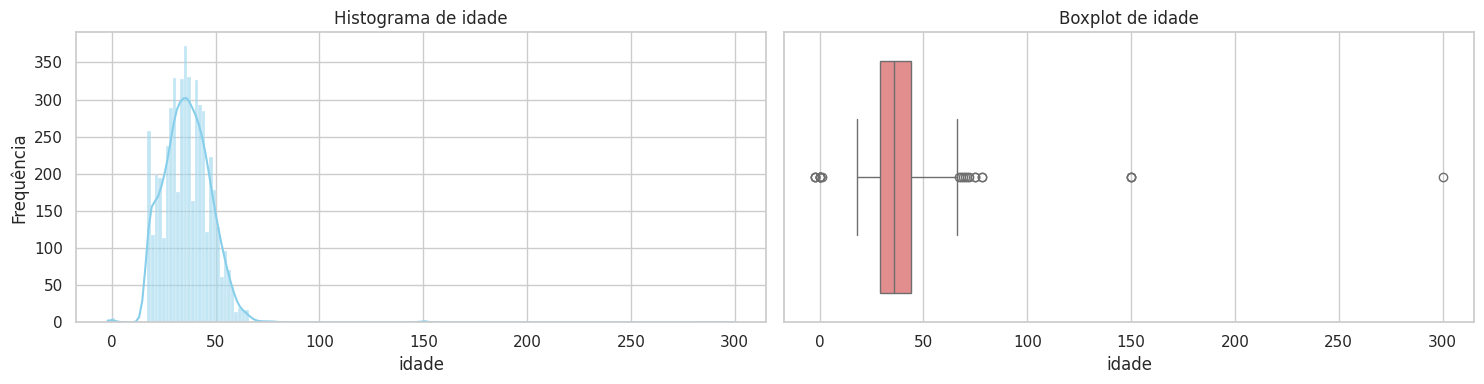

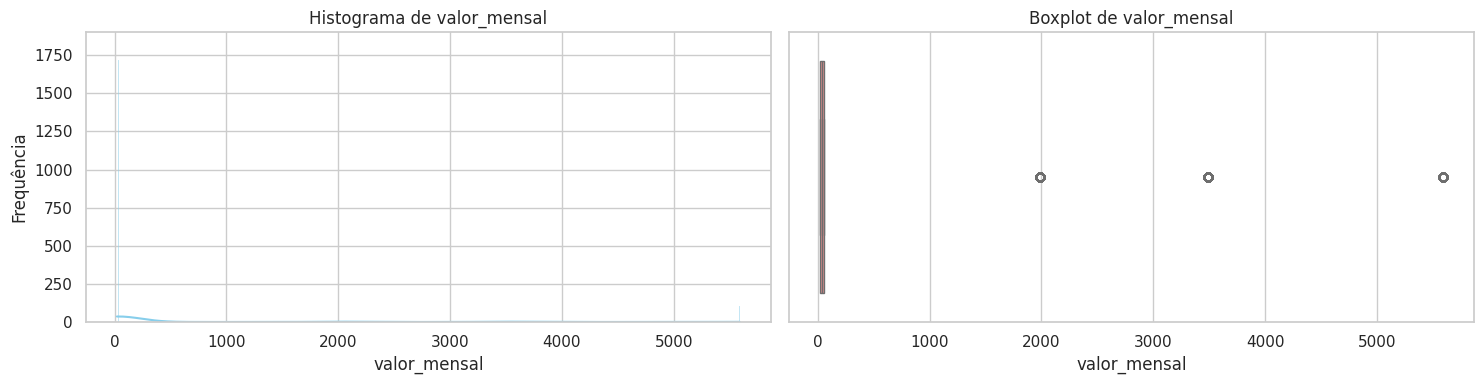

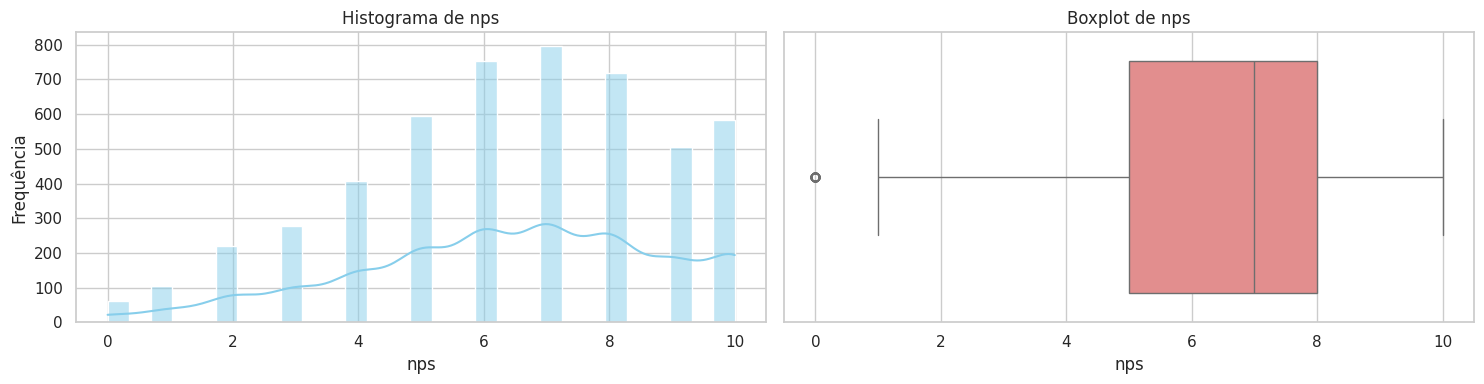

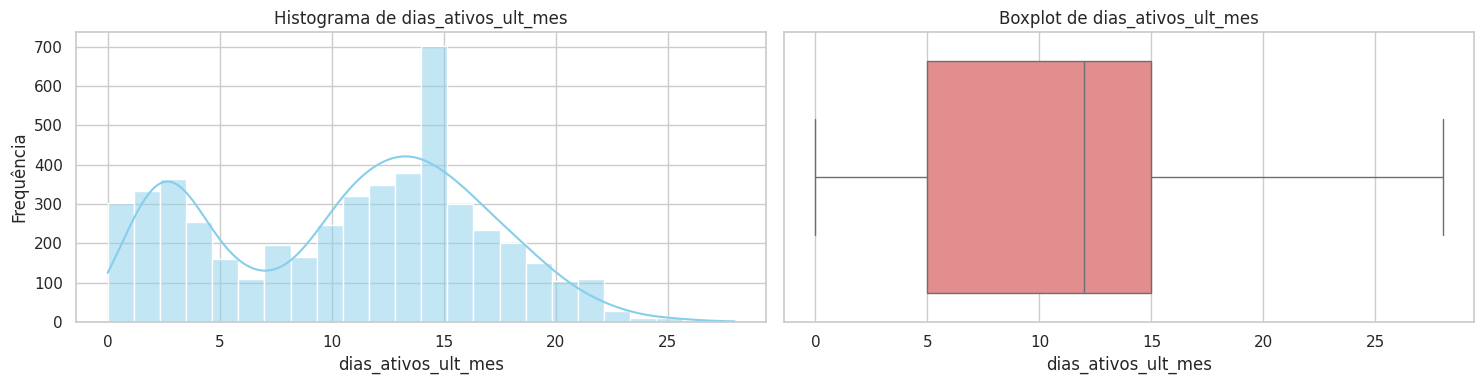

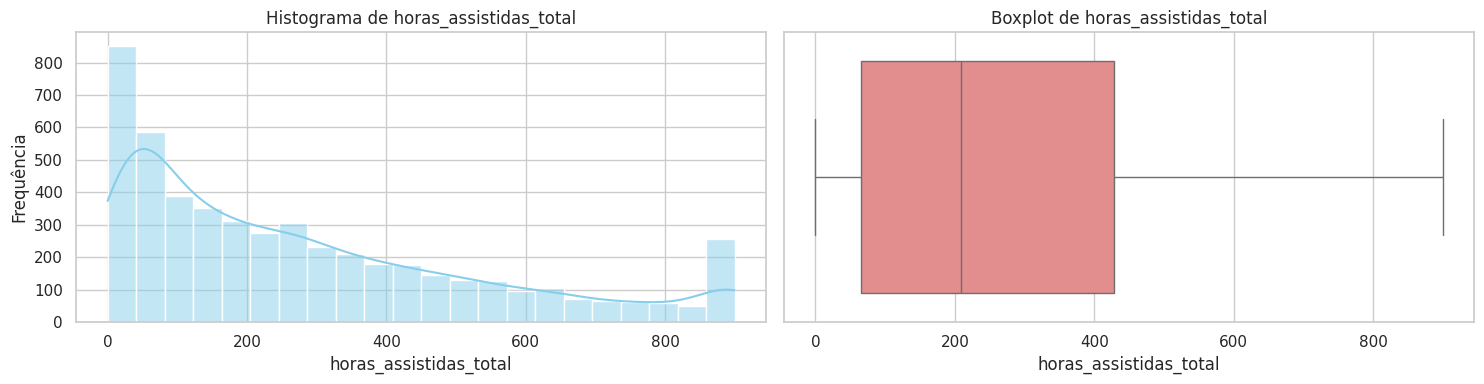

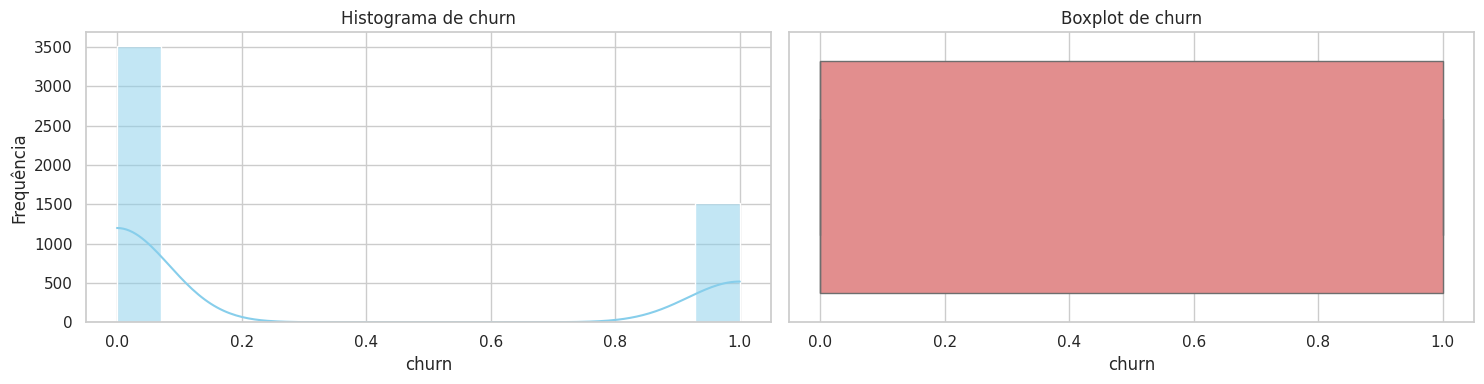

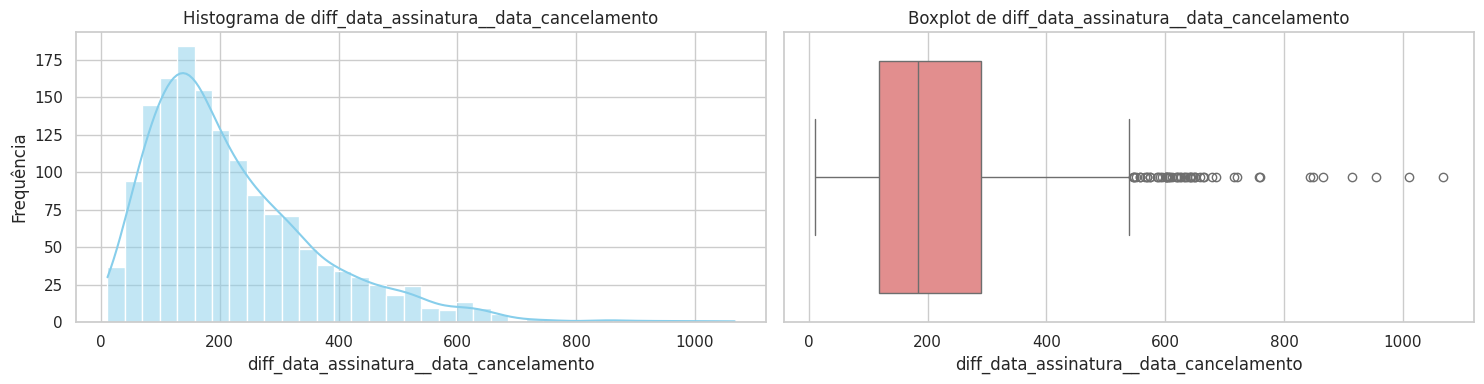

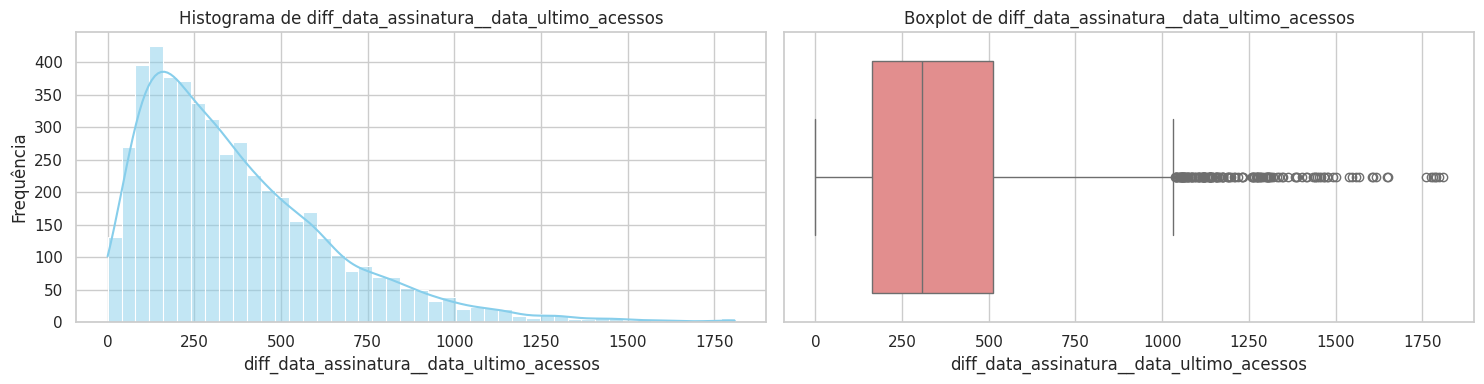

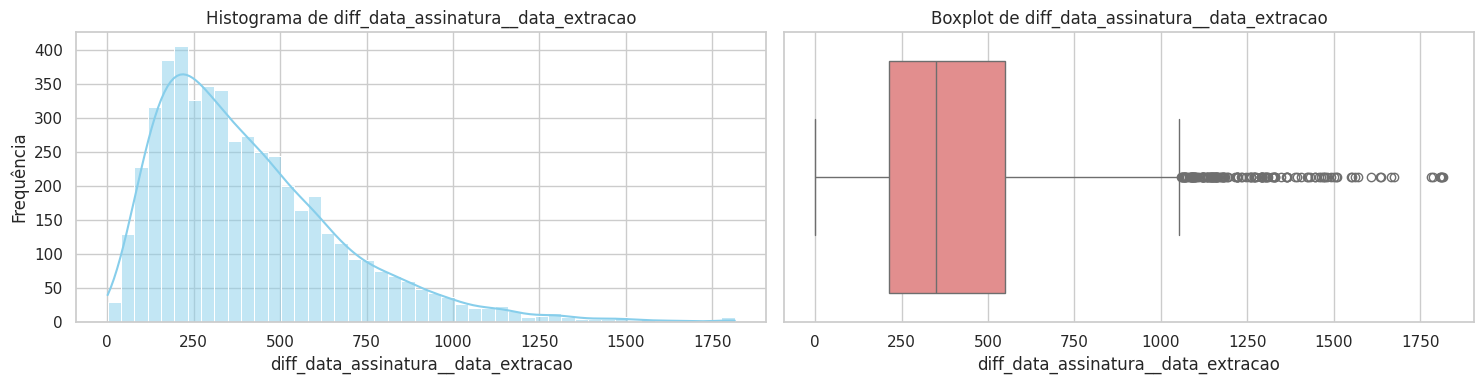

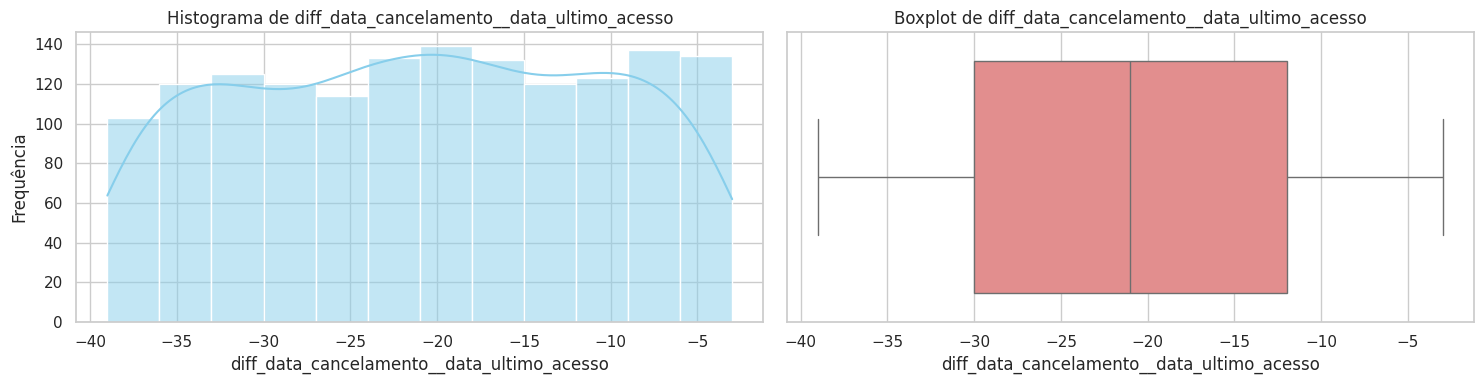

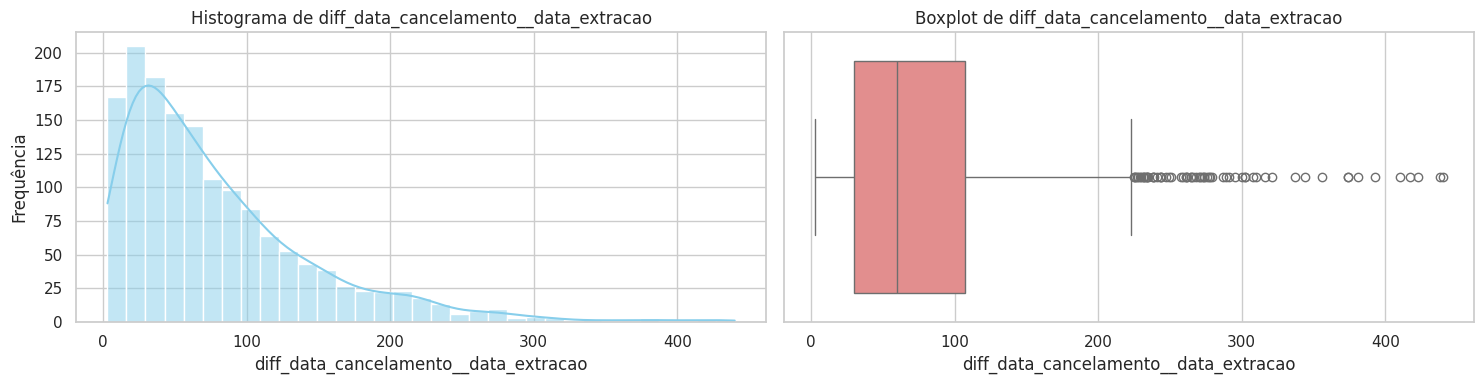

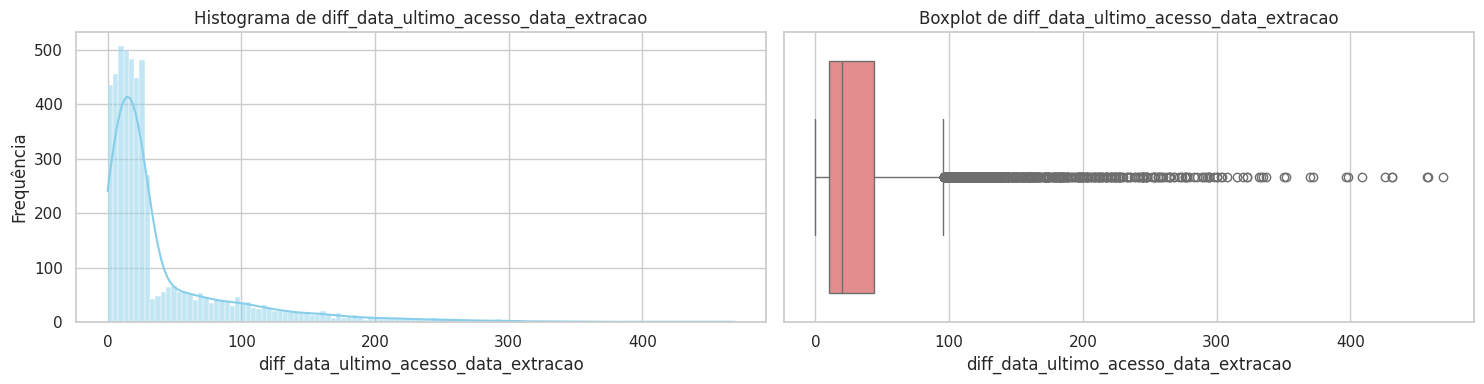

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrando as colunas numéricas para excluir 'cliente_id'
colunas_plot = [col for col in colunas_numericas if col != 'cliente_id']

sns.set_theme(style="whitegrid")

# Gerando um histograma e um boxplot para cada coluna numérica
for col in colunas_plot:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Histograma
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histograma de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequência')

    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

In [14]:
# Armazena a quantidade de linhas antes do filtro
linhas_antes = df_novo_filtro.shape[0]

# Aplica o filtro de idade (mantendo apenas >= 18 e <= 90)
df_novo_filtro = df_novo_filtro[(df_novo_filtro['idade'] >= 18) & (df_novo_filtro['idade'] <= 90)].copy()

# Exibe o resultado do filtro
linhas_depois = df_novo_filtro.shape[0]
print(f"Quantidade de linhas antes do filtro: {linhas_antes}")
print(f"Quantidade de linhas após o filtro de idade (18 a 90 anos): {linhas_depois}")
print(f"Total de linhas removidas: {linhas_antes - linhas_depois}")

Quantidade de linhas antes do filtro: 5024
Quantidade de linhas após o filtro de idade (18 a 90 anos): 5011
Total de linhas removidas: 13


In [15]:
# Filtra as linhas onde o valor mensal é superior a 1000
valores_altos = df_novo_filtro[df_novo_filtro['valor_mensal'] > 1000]

# Exibe a quantidade de linhas encontradas e os registros
print(f"Total de registros com valor mensal > 1000: {valores_altos.shape[0]}")
display(valores_altos)

Total de registros com valor mensal > 1000: 602


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,data_ultimo_acesso,data_extracao,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acessos,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso_data_extracao
3,3454,46,básico,Anual,1990.0,Sul,google,10,2023-04-02,NaT,2024-01-13,2024-01-31,19,385.0,NaN,0,NaN,286.0,304,NaN,NaN,18.0
14,5581,18,padrão,Mensal,3490.0,Sudeste,orgânico,7,2023-07-22,NaT,2024-01-27,2024-01-31,15,160.7,NaN,0,NaN,189.0,193,NaN,NaN,4.0
29,5979,31,padrão,Mensal,3490.0,Sudeste,instagram,10,2023-08-22,NaT,2024-01-03,2024-01-31,14,117.2,NaN,0,NaN,134.0,162,NaN,NaN,28.0
34,1433,56,padrão,Anual,3490.0,NaN,orgânico,9,2023-04-14,NaT,2024-01-22,2024-01-31,11,180.4,NaN,0,NaN,283.0,292,NaN,NaN,9.0
42,4776,61,básico,Anual,1990.0,Sudeste,orgânico,4,2023-10-01,2023-12-15,2023-11-25,2024-01-31,6,47.8,problema tecnico,1,75.0,55.0,122,-20.0,47.0,67.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4979,4984,30,padrão,Anual,3490.0,Sudeste,indicação,7,2020-12-01,NaT,2024-01-13,2024-01-31,20,900.0,NaN,0,NaN,1138.0,1156,NaN,NaN,18.0
4991,2396,23,padrão,Anual,3490.0,Nordeste,orgânico,8,2021-04-14,NaT,2024-01-26,2024-01-31,18,900.0,NaN,0,NaN,1017.0,1022,NaN,NaN,5.0
5000,5926,37,padrão,Anual,3490.0,Centro-Oeste,orgânico,10,2022-12-01,NaT,2024-01-07,2024-01-31,9,243.6,NaN,0,NaN,402.0,426,NaN,NaN,24.0
5006,4388,18,básico,Anual,1990.0,Nordeste,instagram,9,2023-05-03,NaT,2024-01-09,2024-01-31,11,160.6,NaN,0,NaN,251.0,273,NaN,NaN,22.0


In [16]:
# Contagem de valores distintos na coluna valor_mensal
print("=== Quantidade de valores únicos em 'valor_mensal' ===")
print(df_novo_filtro['valor_mensal'].nunique())

print("\n=== Contagem de cada valor único em 'valor_mensal' ===")
display(df_novo_filtro['valor_mensal'].value_counts())

=== Quantidade de valores únicos em 'valor_mensal' ===
6

=== Contagem de cada valor único em 'valor_mensal' ===


,count
valor_mensal,
19.9,1806
34.9,1712
55.9,891
1990.0,252
3490.0,246
5590.0,104


In [17]:
# Aplica a divisão por 100 para valores acima de 1900 na coluna valor_mensal
df_novo_filtro.loc[df_novo_filtro['valor_mensal'] > 1900, 'valor_mensal'] = df_novo_filtro.loc[df_novo_filtro['valor_mensal'] > 1900, 'valor_mensal'] / 100

# Exibe a nova contagem de valores distintos para validar a alteração
print("=== Nova contagem de valores distintos em 'valor_mensal' ===")
display(df_novo_filtro['valor_mensal'].value_counts())

=== Nova contagem de valores distintos em 'valor_mensal' ===


,count
valor_mensal,
19.9,2058
34.9,1958
55.9,995


In [18]:
import numpy as np

# 1. recencia
df_novo_filtro['recencia'] = df_novo_filtro['diff_data_ultimo_acesso_data_extracao']

# 2. meses_assinatura
condicao_ativo = df_novo_filtro['data_cancelamento'].isnull()
dias_assinatura = np.where(
    condicao_ativo,
    (df_novo_filtro['data_extracao'] - df_novo_filtro['data_assinatura']).dt.days,
    df_novo_filtro['diff_data_assinatura__data_cancelamento']
)
df_novo_filtro['meses_assinatura'] = dias_assinatura / 30.0

# 3. receita_acumulada
df_novo_filtro['receita_acumulada'] = df_novo_filtro['valor_mensal'] * df_novo_filtro['meses_assinatura']

# Exibir as novas colunas criadas
display(df_novo_filtro[['cliente_id', 'recencia', 'meses_assinatura', 'receita_acumulada']].head())

,cliente_id,recencia,meses_assinatura,receita_acumulada
0,5746,2.0,9.833333,195.683333
1,4100,1.0,20.266667,707.306667
2,4690,457.0,20.233333,1131.043333
3,3454,18.0,10.133333,201.653333
4,1437,15.0,9.500000,189.050000


In [19]:
# Seleciona apenas as novas colunas
novas_colunas_calculadas = ['recencia', 'meses_assinatura', 'receita_acumulada']

print("=== Informações Gerais das Novas Colunas ===")
display(df_novo_filtro[novas_colunas_calculadas].info())

print("\n=== Estatísticas Descritivas das Novas Colunas ===")
display(df_novo_filtro[novas_colunas_calculadas].describe())

=== Informações Gerais das Novas Colunas ===
<class 'pandas.core.frame.DataFrame'>
Index: 5011 entries, 0 to 5024
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   recencia           4961 non-null   float64
 1   meses_assinatura   5011 non-null   float64
 2   receita_acumulada  5011 non-null   float64
dtypes: float64(3)
memory usage: 156.6 KB


None


=== Estatísticas Descritivas das Novas Colunas ===


,recencia,meses_assinatura,receita_acumulada
count,4961.000000,5011.000000,5011.000000
mean,40.452731,12.950376,428.914295
std,55.112223,9.186362,371.527653
min,0.000000,0.033333,0.663333
25%,10.000000,6.033333,168.585000
50%,20.000000,10.766667,321.080000
75%,44.000000,17.600000,570.033333
max,469.000000,60.500000,2893.756667


In [20]:
# Cria o novo DataFrame 'df_analise' a partir de 'df_novo_filtro'
df_analise = df_novo_filtro[df_novo_filtro['diff_data_assinatura__data_extracao'] >= 220].copy()

# Exibe o número de linhas resultantes e uma amostra dos dados
print(f"Quantidade de registros no DataFrame 'df_analise': {df_analise.shape[0]} (antes: {df_novo_filtro.shape[0]} no 'df_novo_filtro')")
display(df_analise.head())

Quantidade de registros no DataFrame 'df_analise': 3668 (antes: 5011 no 'df_novo_filtro')


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,data_ultimo_acesso,data_extracao,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acessos,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso_data_extracao,recencia,meses_assinatura,receita_acumulada
0,5746,36,básico,Anual,19.9,Sudeste,indicação,6,2023-04-11,NaT,2024-01-29,2024-01-31,15,276.0,NaN,0,NaN,293.0,295,NaN,NaN,2.0,2.0,9.833333,195.683333
1,4100,48,padrão,Mensal,34.9,Sudeste,orgânico,8,2022-06-02,NaT,2024-01-30,2024-01-31,14,394.9,NaN,0,NaN,607.0,608,NaN,NaN,1.0,1.0,20.266667,707.306667
2,4690,48,premium,Mensal,55.9,Nordeste,orgânico,4,2021-03-20,2022-11-17,2022-10-31,2024-01-31,5,257.0,PREÇO,1,607.0,590.0,1047,-17.0,440.0,457.0,457.0,20.233333,1131.043333
3,3454,46,básico,Anual,19.9,Sul,google,10,2023-04-02,NaT,2024-01-13,2024-01-31,19,385.0,NaN,0,NaN,286.0,304,NaN,NaN,18.0,18.0,10.133333,201.653333
4,1437,46,básico,Mensal,19.9,Norte,indicação,8,2023-04-21,NaT,2024-01-16,2024-01-31,11,205.3,NaN,0,NaN,270.0,285,NaN,NaN,15.0,15.0,9.500000,189.050000



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: idade ==============================


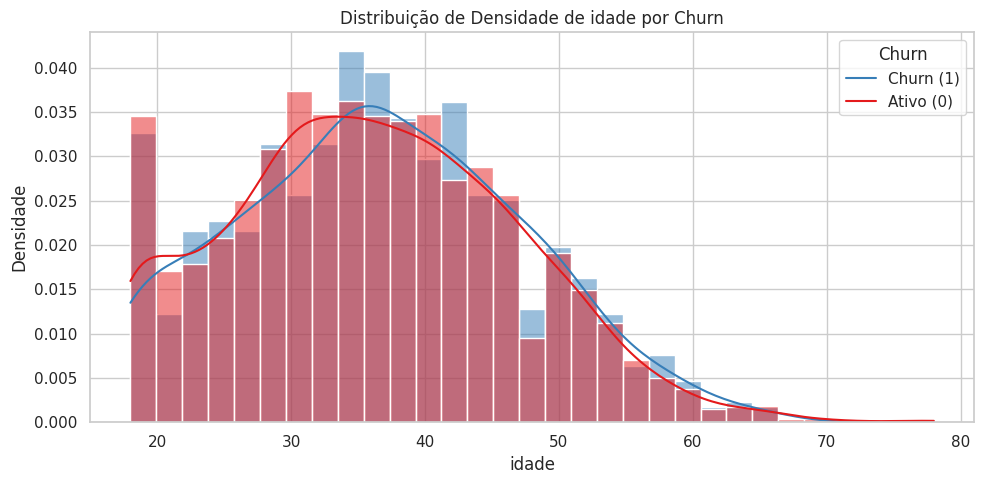


Estatísticas de idade agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2780.0,36.125540,10.633567,18.0,29.0,36.0,44.0,78.0
1,888.0,36.632883,10.600266,18.0,29.0,36.0,44.0,66.0



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: valor_mensal ==============================


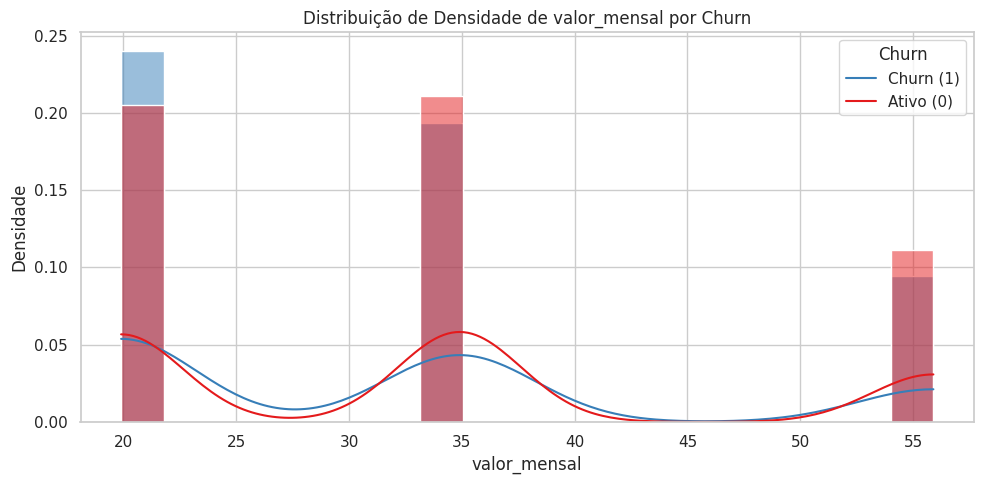


Estatísticas de valor_mensal agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2780.0,33.496043,13.370968,19.9,19.9,34.9,34.9,55.9
1,888.0,31.835811,13.119920,19.9,19.9,34.9,34.9,55.9



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: nps ==============================


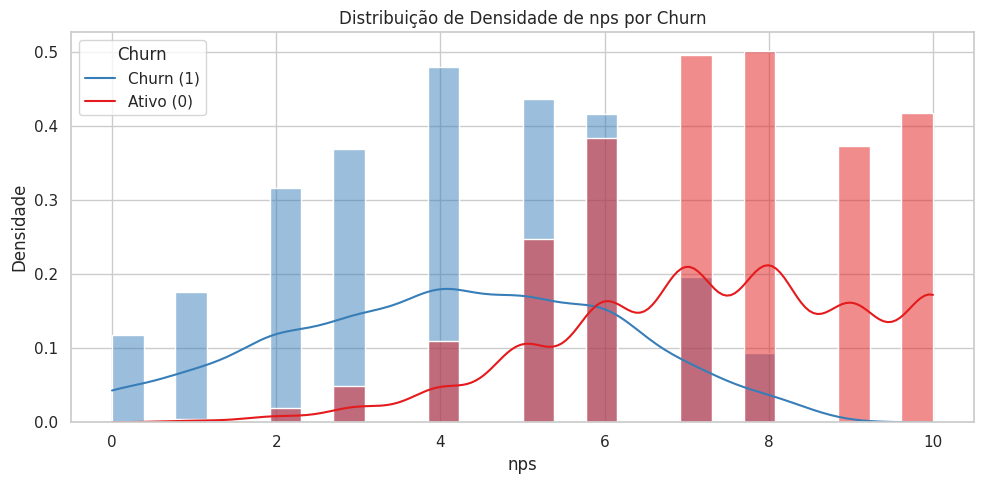


Estatísticas de nps agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2780.0,7.376978,1.877014,1.0,6.0,7.0,9.0,10.0
1,888.0,4.090090,2.004165,0.0,3.0,4.0,6.0,8.0



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: dias_ativos_ult_mes ==============================


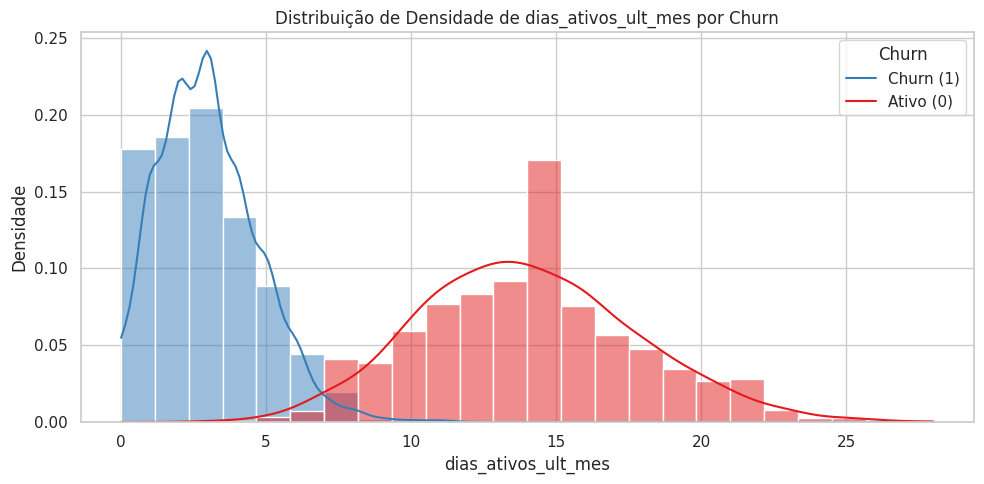


Estatísticas de dias_ativos_ult_mes agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2780.0,13.995324,3.755046,3.0,11.0,14.0,16.0,28.0
1,888.0,2.967342,1.721950,0.0,2.0,3.0,4.0,11.0



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: horas_assistidas_total ==============================


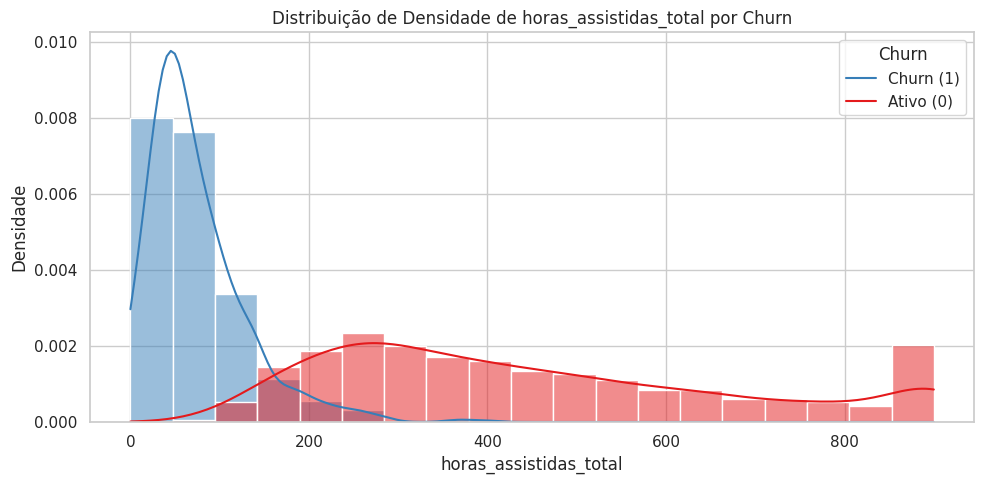


Estatísticas de horas_assistidas_total agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2780.0,448.891475,226.739374,73.9,265.450,395.60,600.9,900.0
1,888.0,73.143131,55.191559,0.0,35.925,58.95,96.6,400.0



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: diff_data_assinatura__data_ultimo_acessos ==============================


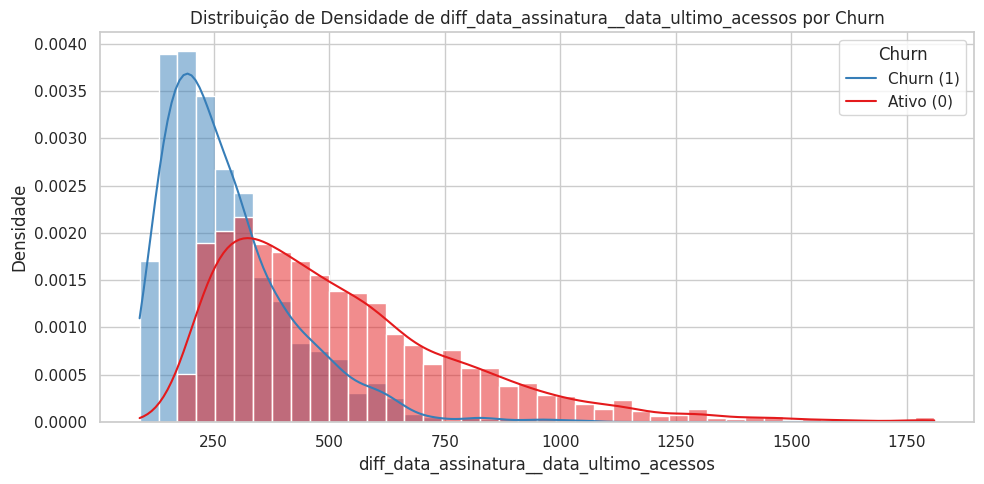


Estatísticas de diff_data_assinatura__data_ultimo_acessos agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2755.0,528.301270,266.179458,192.0,327.0,465.0,659.0,1809.0
1,878.0,278.715262,138.580418,90.0,176.0,244.0,342.5,1040.0



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: diff_data_assinatura__data_extracao ==============================


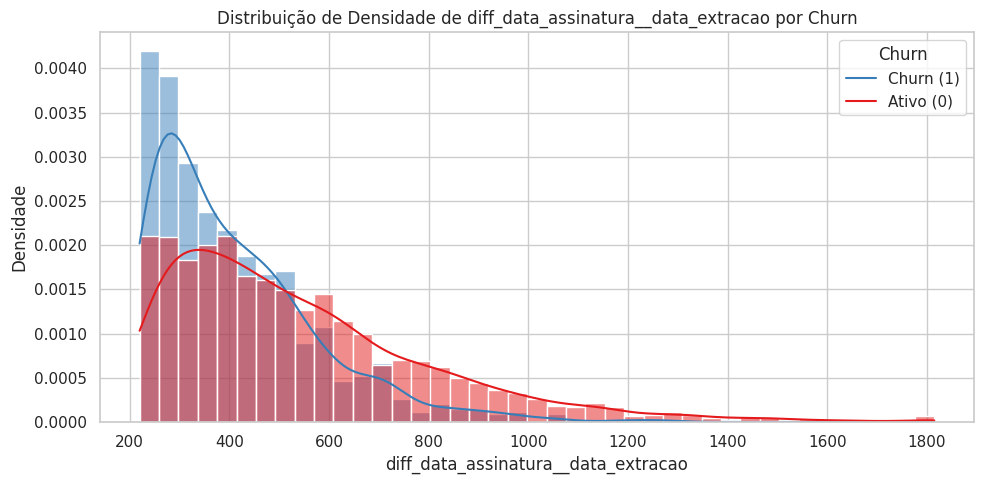


Estatísticas de diff_data_assinatura__data_extracao agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2780.0,542.666187,265.461831,220.0,341.0,481.0,673.25,1815.0
1,888.0,409.548423,166.733604,220.0,282.0,364.5,495.00,1276.0



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: recencia ==============================


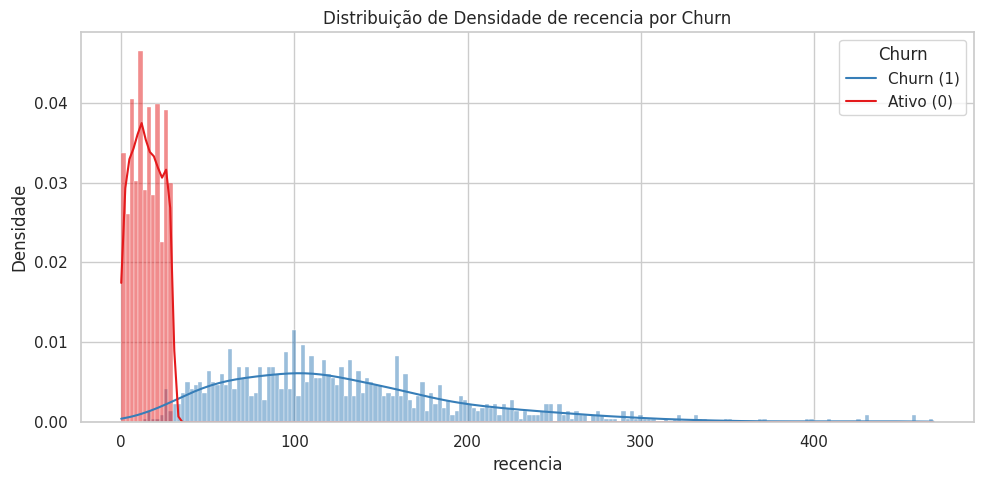


Estatísticas de recencia agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2755.0,14.603993,8.493044,0.0,8.00,14.0,22.0,29.0
1,878.0,130.011390,74.106997,13.0,75.25,117.0,165.0,469.0



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: meses_assinatura ==============================


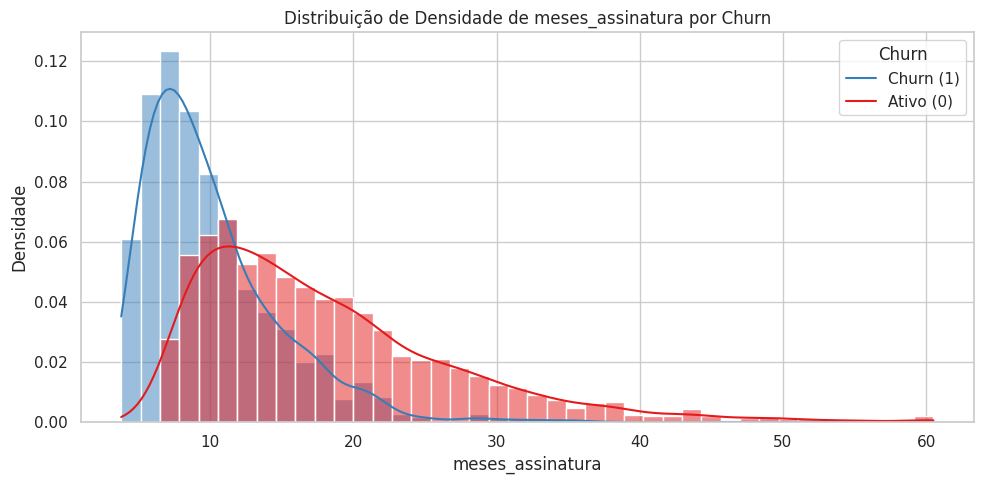


Estatísticas de meses_assinatura agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2780.0,18.088873,8.848728,7.333333,11.366667,16.033333,22.441667,60.500000
1,888.0,10.006156,4.615595,3.800000,6.666667,8.900000,12.108333,35.566667



============================== ANÁLISE DA VARIÁVEL NUMÉRICA: receita_acumulada ==============================


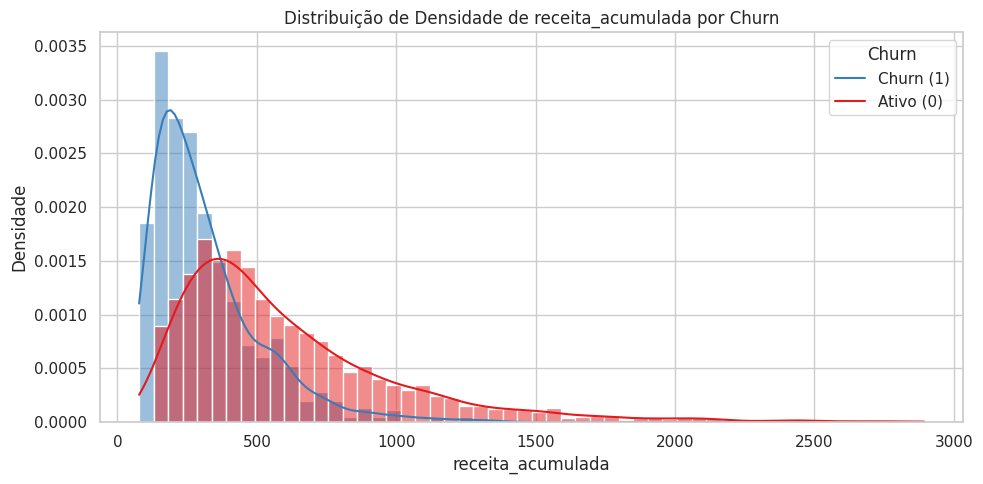


Estatísticas de receita_acumulada agrupadas por Churn:


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2780.0,605.311556,396.917467,145.933333,329.013333,491.508333,762.103333,2893.756667
1,888.0,315.519917,195.137065,77.610000,172.173333,262.680000,392.043333,1341.600000


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

vars_numericas = [
    'idade', 'valor_mensal', 'nps', 'dias_ativos_ult_mes',
    'horas_assistidas_total', 'diff_data_assinatura__data_ultimo_acessos',
    'diff_data_assinatura__data_extracao', 'recencia',
    'meses_assinatura', 'receita_acumulada'
]

for var in vars_numericas:
    if var in df_analise.columns:
        print(f"\n{'='*30} ANÁLISE DA VARIÁVEL NUMÉRICA: {var} {'='*30}")

        # 1. Histograma de densidade sobreposto
        plt.figure(figsize=(10, 5))
        sns.histplot(data=df_analise, x=var, hue='churn', kde=True, stat='density', common_norm=False, palette='Set1', alpha=0.5)
        plt.title(f'Distribuição de Densidade de {var} por Churn')
        plt.xlabel(var)
        plt.ylabel('Densidade')
        plt.legend(title='Churn', labels=['Churn (1)', 'Ativo (0)'])
        plt.tight_layout()
        plt.show()

        # 2. Tabela de estatísticas descritivas por grupo
        print(f"\nEstatísticas de {var} agrupadas por Churn:")
        estatisticas = df_analise.groupby('churn')[var].describe()
        display(estatisticas)
    else:
        print(f"Aviso: A coluna '{var}' não foi encontrada no DataFrame df_analise.")

In [22]:
print(f"{'='*30} TAXA DE CHURN POR VARIÁVEL CATEGÓRICA {'='*30}\n")

vars_categoricas = ['plano', 'ciclo', 'regiao', 'canal_aquisicao']

for var in vars_categoricas:
    if var in df_analise.columns:
        print(f"=== Taxa de Churn por {var} ===")
        # Agrupa pela variável, calcula a média do Churn (que equivale à taxa) e converte para porcentagem
        taxa_churn = df_analise.groupby(var)['churn'].agg(Total_Clientes='count', Taxa_Churn_Pct=lambda x: x.mean() * 100).reset_index()
        taxa_churn['Taxa_Churn_Pct'] = taxa_churn['Taxa_Churn_Pct'].map('{:.2f}%'.format)
        display(taxa_churn)
        print("\n")
    else:
        print(f"Aviso: A coluna '{var}' não foi encontrada no DataFrame df_analise.\n")

============================== TAXA DE CHURN POR VARIÁVEL CATEGÓRICA ==============================

=== Taxa de Churn por plano ===


,plano,Total_Clientes,Taxa_Churn_Pct
0,básico,1486,27.19%
1,padrão,1436,22.63%
2,premium,746,21.31%




=== Taxa de Churn por ciclo ===


,ciclo,Total_Clientes,Taxa_Churn_Pct
0,Anual,916,24.02%
1,Mensal,2752,24.27%




=== Taxa de Churn por regiao ===


,regiao,Total_Clientes,Taxa_Churn_Pct
0,Centro-Oeste,353,26.35%
1,Nordeste,719,23.92%
2,Norte,297,25.59%
3,Sudeste,1464,23.09%
4,Sul,707,24.61%




=== Taxa de Churn por canal_aquisicao ===


,canal_aquisicao,Total_Clientes,Taxa_Churn_Pct
0,google,635,27.09%
1,indicação,797,22.71%
2,instagram,1125,24.89%
3,orgânico,1111,22.95%


## Análise de Pareto dos Motivos de Cancelamento
Nesta etapa, realizamos a normalização dos motivos de cancelamento (removendo acentos, padronizando para minúsculas e eliminando espaços em branco extras) e construímos uma tabela e um gráfico de Pareto para identificar as principais causas de cancelamento na base total (`df_novo_filtro`).

##Conclusões da univariada — variáveis categóricas

**1. Base suja **

• plano: "Basico" / "BASICO" / "básico" são o mesmo plano, mas contam
  separado (708 + 677 + 677). O mesmo com Padrão (3 formas) e Premium
  formas). Sem unificar, você teria 8 planos quando existem 3.

**• canal_aquisicao: ** pior ainda — 9 grafias para 4 canais.
  "Organico"/"orgânico", "Indicacao"/"indicação",
  "IG"/"Instagram"/"instagram", "Google"/"google".


**2. O `?` na região é ausente disfarçado ** São 170 registros com "?", que o `isnull()` não pega porque é texto. Representa ~3,4% da base sem região informada. Tratá-lo como categoria válida criaria uma "região Interrogação" nos gráficos; o certo foi convertê-lo em nulo.

**3. Insight de negócio real ** — a base é fortemente concentrada no Sudeste.
Somando as regiões válidas: Sudeste (2.057) sozinho é ~42% da base, mais que Nordeste (964) e Sul (938) juntos parciais. Norte (408) e Centro-Oeste (488) são pequenos. Isso importa para qualquer análise regional depois — há Sudeste de sobra para conclusões robustas, mas Norte tem amostra pequena, então taxa de churn dessa região terá muito mais incerteza.

**4. Insight de negócio ** — o produto é predominantemente mensal. Mensal
(3.794) contra Anual (1.231): ~75% da base paga mês a mês.

**5. A distribuição dos canais é equilibrada **— nenhum domina. Depois de
unificar: Orgânico (1.510), Instagram (1.547), Indicação (1.082), Google (886).
Aquisição diversificada, sem dependência perigosa de um único canal. Saudável do ponto de vista de risco de aquisição.

## Análise de Pareto dos Motivos de Cancelamento
Nesta seção, normalizamos a coluna `motivo_cancelamento` para remover variações de escrita e criamos uma tabela e um gráfico de Pareto para identificar os principais ofensores.

#Cuidados importantes com conclusões precipitadas

dias_ativos_ult_mes — Quem já deu churn não teve acesso nos últimos meses, então aparece zerado por definição — não porque usava pouco, mas porque já tinha saído.

data_ultimo_acesso (e a recência derivada dela) — Mesma contaminação. Para quem cancelou, o último acesso trava perto da data de saída, então a recência reflete o churn que já aconteceu, não um comportamento que o antecede. Serve para descrever engajamento entre ativos, mas como preditor de churn é enganosa.

horas_assistidas_total — Viés parcial em 2 frentes. Primeiro, quem deu churn parou de assistir antes de sair, então acumula menos horas naturalmente, não é uma CAUSA do churn prévio. Segundo, é confundido pelo tempo de casa: veterano naturalmente acumula mais horas — legal ser normalizada por meses assinatura para comparar de forma justa

meses_assinatura — entre os clientes maduros, quem permanece ativo tem mais tempo de casa acumulado do que quem cancelou, o que é esperado — cliente que não dá churn continua na base acumulando meses, enquanto o churner congela no cancelamento. A leitura honesta é descritiva: os sobreviventes são, por natureza, mais antigos, e há um sinal real de que quem cancela tende a durar menos. Vale só a ressalva de não transformar isso diretamente numa regra preditiva (“abaixo de X meses = risco”), porque o tempo do churner está fechado e o do ativo ainda corre — a forma rigorosa de medir essa queda de permanência ao longo do tempo é a análise de cohort, que desdobra essa diferença agregada na curva de retenção mês a mês.

tempo até o churn (data_cancelamento – data_assinatura) — Só existe para quem deu churn (cancelamento é vazio nos ativos). Não entra em comparação churn vs não-churn; serve para entender quando o churn acontece — foi daí que saíram os 220 dias.

tempo desde o último acesso até o cancelamento (data_cancelamento – data_ultimo_acesso) — Também exclusiva de quem cancelou. Descreve o comportamento de saída, não entra em comparação churn vs não-churn.

Qualquer diferença que envolva data_ultimo_acesso ou data_cancelamento carrega o churn dentro dela, porque essas duas datas são marcadas pelo próprio desfecho.

As diferenças “limpas” para entender padrão churn x não-churn são as que dependem só de data_assinatura e data_extracao (a maturidade) — e mesmo essa exige o corte para não enganar.


## Análise de Pareto dos Motivos de Cancelamento

Nesta seção, realizamos o tratamento e a normalização dos motivos de cancelamento na base total (`df_novo_filtro`) para consolidar variações de escrita e, em seguida, construímos o gráfico de Pareto correspondente.

In [23]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

# Função para normalizar e remover acentos
def sem_acento(s):
    if pd.isna(s):
        return np.nan
    return (unicodedata.normalize('NFKD', str(s))
            .encode('ascii', 'ignore').decode('ascii').strip())

# Aplicando a normalização na coluna do df_novo_filtro
df_novo_filtro['motivo_cancelamento'] = df_novo_filtro['motivo_cancelamento'].str.lower().apply(sem_acento)

print("Contagem de valores da coluna 'motivo_cancelamento' após normalização:")
display(df_novo_filtro['motivo_cancelamento'].value_counts(dropna=False))

Contagem de valores da coluna 'motivo_cancelamento' após normalização:


,count
motivo_cancelamento,
NaN,3500
preco,507
pouco conteudo novo,384
problema tecnico,249
falta de tempo,174
concorrente,130
outro,67


In [24]:
# Filtrando apenas quem tem churn == 1 e removendo vazios ou nulos
motivos = df_novo_filtro.loc[df_novo_filtro['churn'] == 1, 'motivo_cancelamento']
motivos = motivos[motivos.notna() & (motivos != '') & (motivos != 'nan')]

# Gerando a tabela de Pareto
pareto = motivos.value_counts().to_frame('qtd')
pareto['%'] = (pareto['qtd'] / pareto['qtd'].sum() * 100).round(1)
pareto['acumulado_%'] = pareto['%'].cumsum().round(1)

print("=== Tabela de Pareto ===")
display(pareto)

# Identificando as causas vitais (até aproximadamente 80% acumulado)
vitais = pareto[pareto['acumulado_%'] <= 85].index.tolist()
print(f"Poucos vitais (~80% dos cancelamentos): {vitais}")

=== Tabela de Pareto ===


,qtd,%,acumulado_%
motivo_cancelamento,,,
preco,507,33.6,33.6
pouco conteudo novo,384,25.4,59.0
problema tecnico,249,16.5,75.5
falta de tempo,174,11.5,87.0
concorrente,130,8.6,95.6
outro,67,4.4,100.0


Poucos vitais (~80% dos cancelamentos): ['preco', 'pouco conteudo novo', 'problema tecnico']


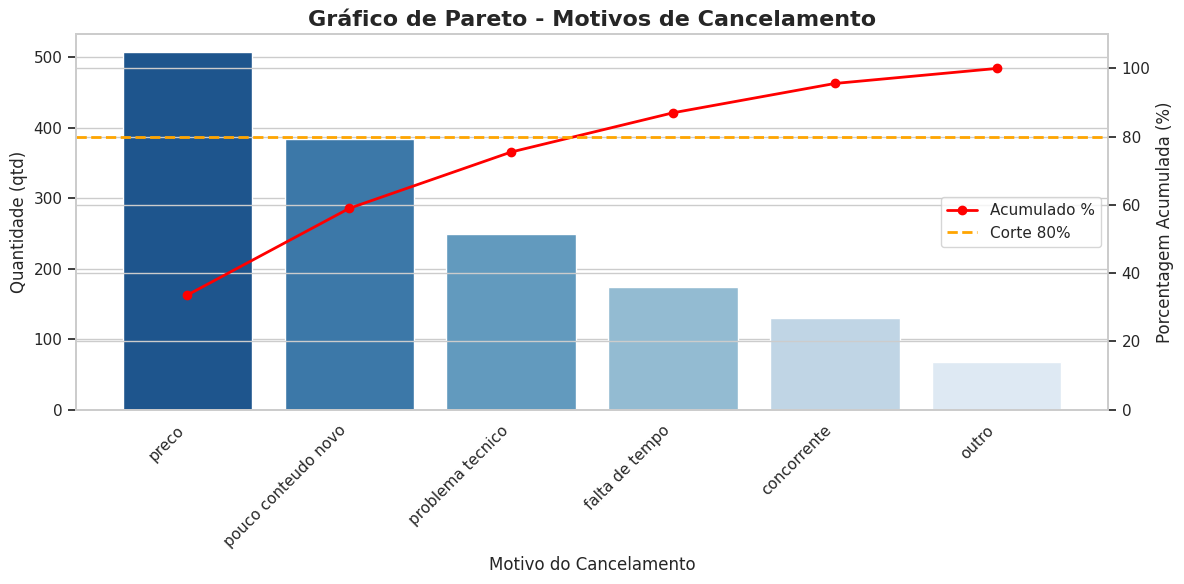

In [27]:
# Plotagem do Gráfico de Pareto
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.set_theme(style="whitegrid")

# Eixo 1: Quantidade por motivo (Barras)
sns.barplot(x=pareto.index, y='qtd', data=pareto, ax=ax1, palette='Blues_r', hue=pareto.index, legend=False)
ax1.set_title('Gráfico de Pareto - Motivos de Cancelamento', fontsize=16, fontweight='bold')
ax1.set_xlabel('Motivo do Cancelamento', fontsize=12)
ax1.set_ylabel('Quantidade (qtd)', fontsize=12)

# Define os ticks fixos antes de setar as etiquetas para evitar o UserWarning
ax1.set_xticks(range(len(pareto.index)))
ax1.set_xticklabels(pareto.index, rotation=45, ha='right')

# Eixo 2: Porcentagem acumulada (Linha)
ax2 = ax1.twinx()
ax2.plot(pareto.index, pareto['acumulado_%'], color='red', marker='o', linewidth=2, label='Acumulado %')
ax2.set_ylabel('Porcentagem Acumulada (%)', fontsize=12)
ax2.set_ylim(0, 110)

# Linha de referência em 80%
ax2.axhline(80, color='orange', linestyle='--', linewidth=2, label='Corte 80%')

# Desempacota corretamente os handles e labels que são retornados como listas dentro de tuplas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()

## Análise do Funil de Conversão do Onboarding

Nesta nova seção, carregamos o arquivo `funil_eventos.csv` para analisar os passos de onboarding dos clientes, removendo registros duplicados para termos dados limpos de eventos.

#Conclusões análise bivariada

Aqui estão os insights só da bivariada, com os números do notebook (recorte maduro, >220 dias):

Premissa: análise feita sobre clientes com pelo menos 220 dias de assinatura — recorte que garante que a pessoa teve tempo real de dar churn.

1. NPS é o sinal mais forte e é um sinal honesto: o NPS é declarado ao longo da relação, não é consequência mecânica do churn. É a primeira candidata a virar alerta precoce de cancelamento.

2. Idade e valor do plano praticamente não separam. Idade idêntica nos dois grupos (36 vs 36) e valor mensal consequência do plano básico x premium. É um achado útil: descarta hipóteses óbvias e evita que o time gaste energia segmentando por essas variáveis.

3. Ciclo e região. Anual e mensal têm composição praticamente igual entre churners e não-churners, e a região, vemos maior diferença de churn no Norte e Centro-oeste. O caso do ciclo é contraintuitivo — o compromisso do plano anual não está segurando ninguém de forma perceptível. (Vale lembrar que 75% da base é mensal, o que reduz o contraste possível.)

4. Canal de aquisição tem efeito leve, mas com valor de negócio. Quem vem de indicação retém um pouco mais do que quem vem do google e outros canais. Conecta com decisão de marketing: a origem do cliente carrega alguma informação sobre a fidelidade dele — canais diferentes trazem clientes com propensões diferentes.

5. As variáveis de engajamento PARECEM separar espetacularmente — armadilha. Dias ativos (14 vs 3), horas assistidas (449 vs 73) e recência (15 vs 130 dias) mostram as maiores diferenças de toda a análise. Mas são contaminadas por vazamento de target: a pessoa parou de usar porque saiu, e não o contrário (o churn causou a variável, não o contrário). A separação é quase circular — elas descrevem o churn que já aconteceu, não o antecipam. Usa-las como "causa" seria o erro mais caro da analise.

## Análise do Funil de Conversão do Onboarding

Carregando e limpando os dados de eventos de onboarding a partir do arquivo próprio `funil_eventos.csv` localizado no Google Drive.

In [28]:
# Definindo o caminho completo do arquivo no Drive
funil_path = '/content/drive/My Drive/Business_Analytics_Fraude/Estatística/funil_eventos.csv'

# Lendo os dados e removendo linhas duplicadas
fn = pd.read_csv(funil_path).drop_duplicates()

# Exibindo o DataFrame resultante
display(fn)

,cliente_id,etapa
0,2165,assistiu_1a_aula
1,3269,criou_conta
2,4589,criou_conta
3,5228,visitou_site
4,4620,assistiu_1a_aula
...,...,...
12881,3327,visitou_site
12882,1268,renovou
12883,5151,visitou_site
12884,4248,visitou_site


## Análise do Funil de Conversão do Onboarding

Aqui padronizamos os nomes das etapas para evitar divergências, montamos a tabela contendo o total de clientes únicos e as respectivas taxas de conversão (relativas à etapa anterior e ao topo do funil), identificamos o maior gargalo e plotamos o gráfico correspondente.

In [29]:
# padroniza a escrita da etapa (unifica "assinou_plano"/"Assinou_Plano"/"assinou plano")
fn['etapa'] = fn['etapa'].astype(str).str.strip().str.lower().str.replace(' ', '_')

ordem = ['visitou_site', 'criou_conta', 'assistiu_1a_aula', 'assinou_plano', 'renovou']

# Monta a estrutura do funil agrupando por etapa e contando clientes únicos
funil = fn.groupby('etapa')['cliente_id'].nunique().reindex(ordem).to_frame('usuarios')

# Calcula a taxa de conversão em relação à etapa anterior
funil['conv_da_etapa_anterior_%'] = (funil['usuarios'] / funil['usuarios'].shift(1) * 100).round(1)
# Para o topo do funil, a conversão é 100%
funil.loc['visitou_site', 'conv_da_etapa_anterior_%'] = 100.0

# Calcula a taxa de conversão em relação ao topo do funil
funil['conv_do_topo_%'] = (funil['usuarios'] / funil.loc['visitou_site', 'usuarios'] * 100).round(1)

print("=== Tabela de Conversão do Funil ===")
display(funil)

=== Tabela de Conversão do Funil ===


,usuarios,conv_da_etapa_anterior_%,conv_do_topo_%
etapa,,,
visitou_site,5000,100.0,100.0
criou_conta,3377,67.5,67.5
assistiu_1a_aula,2698,79.9,54.0
assinou_plano,1066,39.5,21.3
renovou,695,65.2,13.9


Maior gargalo: entrar em assinou_plano — 39.5% de conversão em relação à etapa anterior.



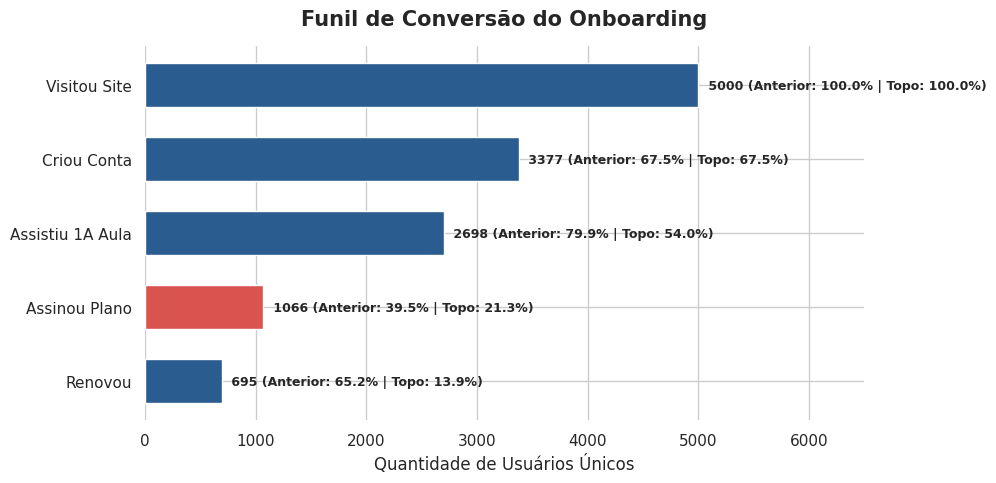

In [30]:
# Identifica a etapa com o menor percentual de conversão em relação à anterior (ignorando o topo do funil)
gargalo = funil.loc['criou_conta':, 'conv_da_etapa_anterior_%'].idxmin()
print(f"Maior gargalo: entrar em {gargalo} — {funil.loc[gargalo, 'conv_da_etapa_anterior_%']}% de conversão em relação à etapa anterior.\n")

# Plotagem do funil como um gráfico de barras horizontais
plt.figure(figsize=(10, 5))

# Define cores diferentes para destacar o gargalo de onboarding
cores = ['#2b5c8f' if e != gargalo else '#d9534f' for e in ordem]

# Barras horizontais organizadas do topo para a base
y_pos = range(len(ordem))[::-1]
plt.barh(y_pos, funil['usuarios'], color=cores, height=0.6)
plt.yticks(y_pos, [e.replace('_', ' ').title() for e in ordem], fontsize=11)
plt.xlabel('Quantidade de Usuários Únicos', fontsize=12)
plt.title('Funil de Conversão do Onboarding', fontsize=15, fontweight='bold', pad=15)

# Adicionando rótulos de valores e percentuais nas barras
for i, (index, row) in enumerate(funil.iterrows()):
    val = row['usuarios']
    pct_prev = row['conv_da_etapa_anterior_%']
    pct_topo = row['conv_do_topo_%']
    label_text = f" {int(val)} (Anterior: {pct_prev}% | Topo: {pct_topo}%)"
    plt.text(val + 50, len(ordem) - 1 - i, label_text, va='center', fontsize=9, fontweight='bold')

plt.xlim(0, funil['usuarios'].max() * 1.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()